In [1]:
import sys, os
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore") 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)
%load_ext autoreload
%autoreload 2

print("Setup complete. src in path:", src_path in sys.path)

Setup complete. src in path: True


In [2]:
SAMPLE_DIR = os.path.abspath("../data/raw_sample")

DATASET = "diabetes_sliced.csv"
TARGET_COL = "diabetes"

MODELS_DIR = os.path.abspath("../models")
RANDOM_STATE = 42

print(f"Dataset: {DATASET} | Target: {TARGET_COL}")


Dataset: diabetes_sliced.csv | Target: diabetes


In [3]:
from data_cleaning import clean_dataset
from feature_engineering import run_pipeline

df_raw = pd.read_csv(os.path.join(SAMPLE_DIR, DATASET))
df_clean, _ = clean_dataset(df_raw)


X_train, X_test, y_train, y_test, artifacts, reports = run_pipeline(
    df_clean, target_col=TARGET_COL,
    processed_dir="../data/processed",
    models_dir=MODELS_DIR,
    random_state=RANDOM_STATE,
)

feature_columns = artifacts["feature_columns"]
print("\nReady:")
print("  X_train:", X_train.shape, "| X_test:", X_test.shape)
print("  features:", len(feature_columns))
print("  class distribution (train):", y_train.value_counts().to_dict())

2026-07-09 18:19:31,086 | data_cleaning | INFO | Cleaning started. Input shape: (20000, 9)
2026-07-09 18:19:31,174 | data_cleaning | INFO | Removed 196 duplicate rows
2026-07-09 18:19:31,195 | data_cleaning | INFO | Skipped 'hypertension' for outliers (2 unique values)
2026-07-09 18:19:31,195 | data_cleaning | INFO | Skipped 'heart_disease' for outliers (2 unique values)
2026-07-09 18:19:31,215 | data_cleaning | INFO | Capped 1492 outliers in 'bmi'
2026-07-09 18:19:31,225 | data_cleaning | INFO | Capped 244 outliers in 'HbA1c_level'
2026-07-09 18:19:31,244 | data_cleaning | INFO | Capped 406 outliers in 'blood_glucose_level'
2026-07-09 18:19:31,252 | data_cleaning | INFO | Skipped 'diabetes' for outliers (2 unique values)
2026-07-09 18:19:31,255 | data_cleaning | INFO | Cleaning finished. Output shape: (19804, 9)
2026-07-09 18:19:31,255 | feature_engineering | INFO | Pipeline started. Input shape: (19804, 9), target: diabetes
2026-07-09 18:19:31,375 | feature_engineering | INFO | Featu


Ready:
  X_train: (15843, 15) | X_test: (3961, 15)
  features: 15
  class distribution (train): {0: 14483, 1: 1360}


In [4]:
IMBALANCE_THRESHOLD = 0.40

def detect_imbalance(y, threshold=IMBALANCE_THRESHOLD):
     counts = y.value_counts()
     props = y.value_counts(normalize=True)
     minority_share = props.min()
     is_imbalanced = minority_share < threshold
     return {
        "class_counts": counts.to_dict(),
        "class_proportions": props.round(3).to_dict(),
        "n_classes": len(counts),
        "minority_share": round(minority_share, 3),
        "is_imbalanced": is_imbalanced,
        "class_weight": "balanced" if is_imbalanced else None,
     }

imbalance_report = detect_imbalance(y_train)

print("Class counts   :", imbalance_report["class_counts"])
print("Class proportions:", imbalance_report["class_proportions"])
print("Minority share   :", imbalance_report["minority_share"])
print(f"Imbalanced (<{IMBALANCE_THRESHOLD})?:", imbalance_report["is_imbalanced"])
print("class_weight  :", imbalance_report["class_weight"])






Class counts   : {0: 14483, 1: 1360}
Class proportions: {0: 0.914, 1: 0.086}
Minority share   : 0.086
Imbalanced (<0.4)?: True
class_weight  : balanced


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def build_models(class_weight=None, random_state=RANDOM_STATE):
    return{
        "LogisticRegression": LogisticRegression(
            class_weight=class_weight, random_state=random_state, max_iter=1000
        ),
        "DecisionTree": DecisionTreeClassifier(
            class_weight=class_weight, random_state=random_state
        ),
        "RandomForest": RandomForestClassifier(
            class_weight=class_weight, random_state=random_state
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=random_state
        ),
    }

models = build_models(class_weight=imbalance_report["class_weight"])
print("Built models (class_weight =", imbalance_report["class_weight"], "):")
for name in models:
    print(" -", name)


Built models (class_weight = balanced ):
 - LogisticRegression
 - DecisionTree
 - RandomForest
 - GradientBoosting


In [6]:
from sklearn.utils.class_weight import compute_sample_weight

gb_sample_weight = None
if imbalance_report["class_weight"] == "balanced":
    gb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

trained_models = {}
training_report = {}

for name, model in models.items():
    try:
        if name == "GradientBoosting" and gb_sample_weight is not None:
            model.fit(X_train, y_train, sample_weight=gb_sample_weight)
            weight_status = "sample_weight=balanced"
        else:
            model.fit(X_train, y_train)
            weight_status = f"class_weight={imbalance_report['class_weight']}" \
                            if name != "GradientBoosting" else "none"
        trained_models[name] = model
        training_report[name] = {"trained": True, "weighting": weight_status}
    except Exception as e:
        training_report[name] = {"trained": False, "error": str(e)}

print("Training complete:")
for name, info in training_report.items():
    print(f"  {name:20s} | {info}")

Training complete:
  LogisticRegression   | {'trained': True, 'weighting': 'class_weight=balanced'}
  DecisionTree         | {'trained': True, 'weighting': 'class_weight=balanced'}
  RandomForest         | {'trained': True, 'weighting': 'class_weight=balanced'}
  GradientBoosting     | {'trained': True, 'weighting': 'sample_weight=balanced'}


In [7]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)

In [8]:
def evaluate_models(models, X_test, y_test, target=None, report_name="model_comparison", reports_dir="../reports"):
    
    results = []
    confusion_matrices = {}
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        # metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test,y_pred,average="weighted",zero_division=0)
        recall = recall_score(y_test,y_pred,average="weighted",zero_division=0)
        f1 = f1_score(y_test,y_pred,average="weighted",zero_division=0)

        # ROC-AUC 
        roc_auc = np.nan
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)
            try:
                if len(np.unique(y_test)) == 2:
                    roc_auc = roc_auc_score(y_test, y_prob[:, 1])
                else:
                    roc_auc = roc_auc_score(
                        y_test,
                        y_prob,
                        multi_class="ovr",
                        average="weighted",
                    )
            except:
                roc_auc = np.nan

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        confusion_matrices[name] = cm
        results.append(
            {
                "Model": name,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1 Score": f1,
                "ROC-AUC": roc_auc,
            }
        )

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)

    if target is not None:
        os.makedirs(reports_dir, exist_ok=True)
        report_path = os.path.join(reports_dir, f"{target}_{report_name}.csv")
        results_df.to_csv(report_path, index=False)
        print(f"Saved comparison report -> {report_path}")

    return results_df, confusion_matrices

In [9]:
results_df,confusion_matrices= evaluate_models(trained_models, X_test, y_test,
                                              target="diabetes", report_name="model_comparison")
print(results_df)

Saved comparison report -> ../reports\diabetes_model_comparison.csv
                Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        RandomForest  0.963393   0.962719  0.963393  0.963018  0.968482
1        DecisionTree  0.959101   0.958481  0.959101  0.958768  0.861908
2    GradientBoosting  0.905579   0.946557  0.905579  0.918353  0.978939
3  LogisticRegression  0.879323   0.939205  0.879323  0.898348  0.962590


In [10]:
data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
}


In [11]:
def tune_models(results_df, data, imb_report, top_n=2, cv_folds=5):
    from sklearn.model_selection import StratifiedKFold

    X_train, y_train = data["X_train"], data["y_train"]
    is_binary = (y_train.nunique() == 2)
    scoring = "f1" if is_binary else "f1_weighted"
    cw = "balanced" if imb_report["is_imbalanced"] else None

    # sample_weight only for Gradient Boosting under imbalance
    sample_weight = None
    if imb_report["is_imbalanced"]:
        from sklearn.utils.class_weight import compute_sample_weight
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

    
    grids = {
        "LogisticRegression": (
            LogisticRegression(max_iter=1000, class_weight=cw),
            {"C": [0.1, 1.0, 10.0], "solver": ["lbfgs", "liblinear"]},
        ),
        "DecisionTree": (
            DecisionTreeClassifier(random_state=42, class_weight=cw),
            {"max_depth": [5, 10, None], "min_samples_split": [2, 10]},
        ),
        "RandomForest": (
            RandomForestClassifier(random_state=42, class_weight=cw),
            {"n_estimators": [100, 200], "max_depth": [10, None],
             "min_samples_split": [2, 5]},
        ),
        "GradientBoosting": (
            GradientBoostingClassifier(random_state=42),
            {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1],
             "max_depth": [3, 5]},
        ),
    }

    candidates = results_df["Model"].head(top_n).tolist()
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    tuned_models = {}
    best_params = {}
    for name in candidates:
        estimator, param_grid = grids[name]
        gs = GridSearchCV(estimator, param_grid, scoring=scoring,
                          cv=skf, n_jobs=-1)
        if name == "GradientBoosting" and sample_weight is not None:
            gs.fit(X_train, y_train, sample_weight=sample_weight)
        else:
            gs.fit(X_train, y_train)
        tuned_models[name] = gs.best_estimator_
        best_params[name] = gs.best_params_

    return tuned_models, best_params

In [12]:
tuned_models, best_params = tune_models(results_df, data, imbalance_report, top_n=2)
for name, params in best_params.items():
    print(f"{name} best params: {params}")

RandomForest best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
DecisionTree best params: {'max_depth': None, 'min_samples_split': 2}


In [13]:
tuned_results,confusion_matrices_tuned = evaluate_models(
    tuned_models, X_test, y_test, target="diabetes",
     report_name="tuned_model_comparison")

print("Baseline (top candidates):")
print(results_df[results_df["Model"].isin(tuned_results["Model"])].to_string(index=False))
print("\nTuned:")
print(tuned_results.to_string(index=False))

Saved comparison report -> ../reports\diabetes_tuned_model_comparison.csv
Baseline (top candidates):
       Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
RandomForest  0.963393   0.962719 0.963393  0.963018 0.968482
DecisionTree  0.959101   0.958481 0.959101  0.958768 0.861908

Tuned:
       Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
RandomForest  0.963898   0.963155 0.963898  0.963477 0.971641
DecisionTree  0.959101   0.958481 0.959101  0.958768 0.861908


Class labels: None


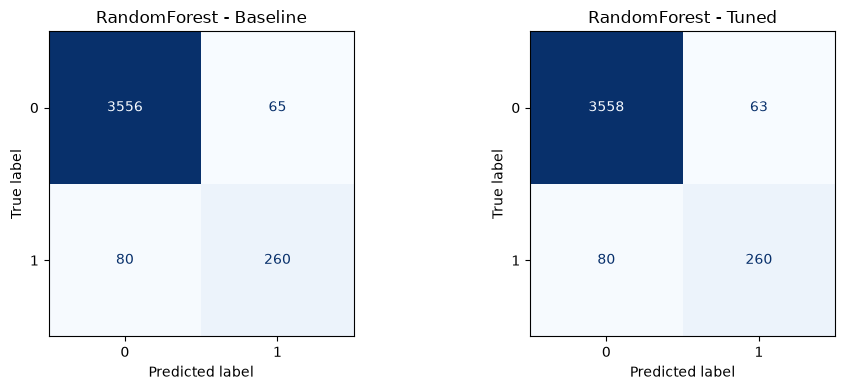

Saved -> ../reports\diabetes_RandomForest_confusion_matrix.png


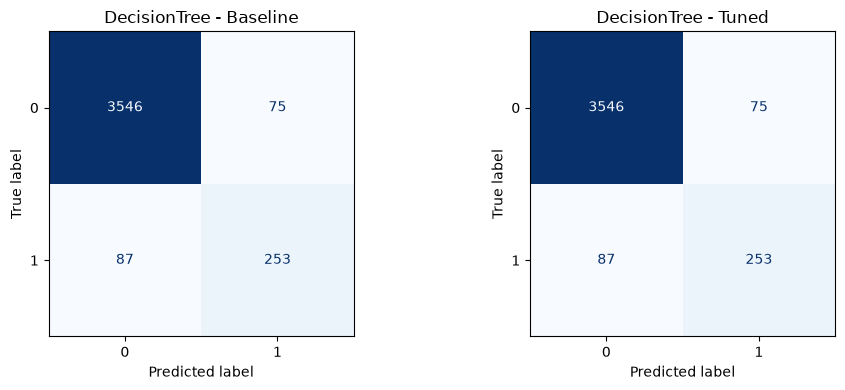

Saved -> ../reports\diabetes_DecisionTree_confusion_matrix.png


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

REPORTS_DIR = "../reports"


def get_class_labels(artifacts, target_col):
    """Get class names from the saved target encoder, else fall back to numbers."""
    target_encoder = artifacts.get("encoders", {}).get("__target__")
    if target_encoder is not None:
        return list(target_encoder.classes_)
    return None   # sklearn will use 0, 1, ...


def plot_baseline_vs_tuned(cm_baseline, cm_tuned, labels=None,
                           prefix="model", reports_dir=REPORTS_DIR):
    """Plot baseline vs tuned confusion matrices side by side and save each."""
    os.makedirs(reports_dir, exist_ok=True)

    for name in [m for m in cm_tuned if m in cm_baseline]:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, stage, cm_dict in zip(axes, ["Baseline", "Tuned"], [cm_baseline, cm_tuned]):
            ConfusionMatrixDisplay(cm_dict[name], display_labels=labels).plot(
                ax=ax, cmap="Blues", colorbar=False
            )
            ax.set_title(f"{name} - {stage}")

        fig.tight_layout()
        path = os.path.join(reports_dir, f"{prefix}_{name}_confusion_matrix.png")
        fig.savefig(path, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print("Saved ->", path)


# Labels auto-detected from the saved target encoder — no hardcoding
class_labels = get_class_labels(artifacts, TARGET_COL)
print("Class labels:", class_labels)

plot_baseline_vs_tuned(
    confusion_matrices, confusion_matrices_tuned,
    labels=class_labels, prefix=TARGET_COL,
)

In [15]:
import joblib

def save_best_model(results_df, models_dict, feature_columns, target_col,
                    models_dir, best_params=None, metric="F1 Score"):
  

    best_row = results_df.sort_values(metric, ascending=False).iloc[0]
    best_name = best_row["Model"]

    # Extract all metric columns dynamically
    metrics = {
        col: (None if pd.isna(best_row[col]) else round(float(best_row[col]), 4))
        for col in results_df.columns if col != "Model"
    }

    bundle = {
        "model": models_dict[best_name],
        "model_name": best_name,
        "feature_columns": list(feature_columns),
        "target_col": target_col,
        "best_params": (best_params or {}).get(best_name),
        "metrics": metrics,
    }

    os.makedirs(models_dir, exist_ok=True)
    path = os.path.join(models_dir, f"{target_col}_best_model.pkl")

    joblib.dump(bundle, path)
    return bundle, path


bundle, path = save_best_model(
    tuned_results, tuned_models, feature_columns, TARGET_COL, MODELS_DIR, best_params
)

print("Best model :", bundle["model_name"])
print("Best params:", bundle["best_params"])
print("Metrics    :", bundle["metrics"])
print("Saved      ->", path)

Best model : RandomForest
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Metrics    : {'Accuracy': 0.9639, 'Precision': 0.9632, 'Recall': 0.9639, 'F1 Score': 0.9635, 'ROC-AUC': 0.9716}
Saved      -> d:\projects\Healthcare\models\diabetes_best_model.pkl
